In [31]:
#colab용 환경설정
# from google.colab import drive
# drive.mount('/content/drive')
# import sys
# sys.path.append('/content/drive/MyDrive/Colab Notebooks/LEVEL 1/torch')
# from multiclass_functions1 import * # * 은 all을 의미
# import torch
# from torch import nn, optim
# from torchvision import datasets, transforms
# import numpy as np
# import matplotlib.pyplot as plt
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# print(DEVICE)

In [34]:
# #마운트 확인 코드
# import os
# print(os.getcwd())
# # print(os.path.isdir("/content/drive"))
# # print(os.listdir("/content/drive")[:5])

In [ ]:
#로컬에서 mac gpu사용 코드
# import torch
# print(torch.__version__)
# print(torch.backends.mps.is_available())
# print(torch.backends.mps.is_built())
# from google.colab import drive
# drive.mount('/content/drive',force_remount=True)
# import sys
# # sys.path.append('/content/drive/MyDrive/Colab Notebooks/LEVEL 1/torch')
# sys.path.append('/content/drive/MyDrive/Colab Notebooks/torch')
# from multiclass_functions1 import * # all , 사용자 모듈에서 모든함수 가져와라
# import torch
# from torch import nn, optim
# from torchvision import datasets, transforms
# import numpy as np
# import matplotlib.pyplot as plt
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# print(DEVICE)
# DEVICE = "mps" if torch.backends.mps.is_available() else "cpu" #맥북 gpu로 돌림
# print(DEVICE)

mps


### /content는 Colab 런타임의 임시 디스크라서 GUI 없이도 파이썬/쉘로 폴더 생성하고 파일을 올릴 수 있습니다. 다만 런타임 끄면 사라집니다.가능한 방법 (GUI/마운트 없이):
- 런타임 종료되면 다시 학습시키거나 저장한 값들이 다 사라지니 중요한 모델이나 다시 불러올모델들은 로컬이나 colab 사용


In [4]:
#로컬에서 확장 colab용 환경설정
# from google.colab import drive
# drive.mount('/content/drive')
# import sys
# sys.path.append('/content/drive/MyDrive/Colab Notebooks/LEVEL 1/torch')
import os
os.makedirs("/content/results", exist_ok=True)
os.makedirs("/content/data", exist_ok=True)
print(os.getcwd())
os.chdir("/content/results") #colab클라우드 런타임에 가상폴더 만들고 이동 

print(os.getcwd())
from multiclass_functions1 import * # * 은 all을 의미
import torch
from torch import nn, optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

/content/results
/content/results
cuda


### new_model_train=True로 놓고 MLP,cnn,cnn_deep모델 다 학습한후(model.train) 평가(model.eval(),with torch.no_grad())해야함

In [ ]:
BATCH_SIZE = 32
LR = 1e-3
EPOCH = 5
criterion = nn.CrossEntropyLoss()
new_model_train = True
#new_model_train = False
model_type = "CNN_deep"
dataset = "CIFAR10"
#save_model_path = f"/content/drive/MyDrive/Colab Notebooks/results/{model_type}_{dataset}.pt" #colab용
#save_model_path = f"/Users/jeonminkyu/Desktop/torch/results/{model_type}_{dataset}.pt" #mac북용
save_model_path = f"/content/results/{model_type}_{dataset}.pt" #vscode확장 colab용

In [ ]:
transform = transforms.ToTensor()
#colab용경로
# train_DS = datasets.CIFAR10(root = '/content/drive/MyDrive/Colab Notebooks/data', train=True, download=True, transform=transform)
# test_DS = datasets.CIFAR10(root = '/content/drive/MyDrive/Colab Notebooks/data', train=False, download=True, transform=transform)
#mac용 경로
#train_DS = datasets.CIFAR10(root = '/Users/jeonminkyu/Desktop/torch/data', train=True, download=True, transform=transform)
#test_DS = datasets.CIFAR10(root = '/Users/jeonminkyu/Desktop/torch/data', train=False, download=True, transform=transform)
#vscode 확장 colab용 경로
train_DS = datasets.CIFAR10(root = '/content/data', train=True, download=True, transform=transform)
test_DS = datasets.CIFAR10(root = '/content/data', train=False, download=True, transform=transform)

train_DL = torch.utils.data.DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
test_DL = torch.utils.data.DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=True)

100%|██████████| 170M/170M [00:05<00:00, 31.2MB/s] 


In [7]:
print(train_DS)
print(test_DS)

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: /content/data
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset CIFAR10
    Number of datapoints: 10000
    Root location: /content/data
    Split: Test
    StandardTransform
Transform: ToTensor()


In [38]:
# 내 필기용: train_DS 으로부터 data 하나씩 볼 수 있음
# for x, y in train_DS:
#     print(x.shape)
#     print(y)
#     break

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}
torch.Size([32, 3, 32, 32])
automobile


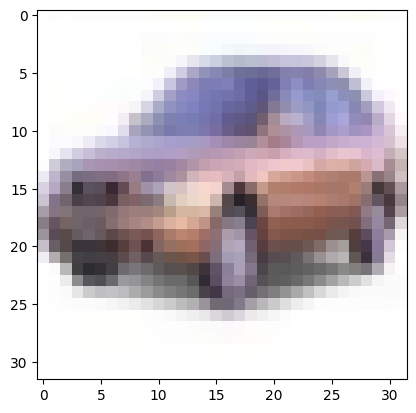

In [8]:
print(test_DS.classes)
print(test_DS.class_to_idx)
x_batch, y_batch = next(iter(train_DL))
print(x_batch.shape)
plt.imshow(x_batch[0].permute(1,2,0))#torch의 텐서(개,체 행,렬)와 다르게 plt에서는 이미지의 높이, 너비,채널을 입력으로 이미지를 받는다.
print(test_DS.classes[y_batch[0]])

In [9]:
x_batch, y_batch = next(iter(train_DL)) # 데이터 한 국자 # next(iter(train_DS)) 는 한장만 꺼내기
# ToTensor 의 역할
# 1. tensor 로 바꾸고
# 2. 개채행열로 바꾸고
# 3. 0~1 사이로 바꾸고 (int -> float)
print(type(train_DS.data)) #기본데이터는 넘파이배열로 되어있음 (채널이 맨마지막, 개 행 렬 채)
print(train_DS.data.shape)
print(train_DS.data.dtype)
print(train_DS.data[0][0][0][0])

print(type(x_batch))
print(x_batch.shape) #dataloader를 통해 totensor를 적용한 데이터인 train_DL은 데이터가 텐서형태로 되어있음(개 채 행 렬)
print(x_batch.dtype)
print(x_batch[0][0][0][0])

<class 'numpy.ndarray'>
(50000, 32, 32, 3)
uint8
59
<class 'torch.Tensor'>
torch.Size([32, 3, 32, 32])
torch.float32
tensor(0.6745)


In [10]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Sequential(nn.Linear(3*32*32, 30),
                                    nn.BatchNorm1d(30),
                                    nn.ReLU(),
                                    nn.Linear(30, 10))
    def forward(self,x):
        x = torch.flatten(x, start_dim=1)
        x = self.linear(x)
        return x

class MLP_shallow(nn.Module): # 내 필기용
    def __init__(self):
        super().__init__()
        self.linear = nn.Sequential(nn.Linear(3*32*32, 100),
                                    nn.BatchNorm1d(100),
                                    nn.ReLU(),
                                    nn.Linear(100, 10))
    def forward(self,x):
        x = torch.flatten(x, start_dim=1)
        x = self.linear(x)
        return x

class MLP_deep(nn.Module): # 내 필기용
    def __init__(self):
        super().__init__()
        self.linear = nn.Sequential(nn.Linear(3*32*32, 75),
                                    nn.BatchNorm1d(75),
                                    nn.ReLU(),
                                    *[i for _ in range(13) for i in [nn.Linear(75, 75),nn.BatchNorm1d(75),nn.ReLU()]],
                                    nn.Linear(75, 10))
    def forward(self,x):
        x = torch.flatten(x, start_dim=1)
        x = self.linear(x)
        return x

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Conv2d(3,8,3, padding=1),
                                   nn.BatchNorm2d(8),
                                   nn.ReLU())
        self.Maxpool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Sequential(nn.Conv2d(8,16,3, padding=1),
                                   nn.BatchNorm2d(16),
                                   nn.ReLU())
        self.Maxpool2 = nn.MaxPool2d(2)
        self.conv3 = nn.Sequential(nn.Conv2d(16,32,3, padding=1),
                                   nn.BatchNorm2d(32),
                                   nn.ReLU())
        self.Maxpool3 = nn.MaxPool2d(2)
        self.fc = nn.Linear(32*4*4,10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.Maxpool1(x)
        x = self.conv2(x)
        x = self.Maxpool2(x)
        x = self.conv3(x)
        x = self.Maxpool3(x)
        x = torch.flatten(x, start_dim=1)
        x = self.fc(x)
        return x

class CNN_deep(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block1 = nn.Sequential(nn.Conv2d(3,32,3,padding=1),
                                         nn.BatchNorm2d(32),
                                         nn.ReLU(),
                                         nn.Conv2d(32,32,3,padding=1),
                                         nn.BatchNorm2d(32),
                                         nn.ReLU())
        self.Maxpool1 = nn.MaxPool2d(2)

        self.conv_block2 = nn.Sequential(nn.Conv2d(32,64,3,padding=1),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU(),
                                         nn.Conv2d(64,64,3,padding=1),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU(),
                                         nn.Conv2d(64,64,3,padding=1),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU())
        self.Maxpool2 = nn.MaxPool2d(2)

        self.conv_block3 = nn.Sequential(nn.Conv2d(64,128,3,padding=1),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU(),
                                         nn.Conv2d(128,128,3,padding=1),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU(),
                                         nn.Conv2d(128,128,3,padding=1),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU())
        self.Maxpool3 = nn.MaxPool2d(2)

        self.classifier = nn.Sequential(nn.Linear(128*4*4,512),
                                        nn.ReLU(),
                                        nn.Linear(512,10))

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.Maxpool1(x)
        x = self.conv_block2(x)
        x = self.Maxpool2(x)
        x = self.conv_block3(x)
        x = self.Maxpool3(x)
        x = torch.flatten(x, start_dim=1)
        x = self.classifier(x)
        return x

In [ ]:
model = globals()[model_type]().to(DEVICE)
print(model)

x_batch, _ = next(iter(train_DL))
print(x_batch.shape)


#모델 평가
# model.eval()
# with torch.no_grad():
#     print(model(x_batch.to(DEVICE)).shape)

CNN_deep(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (Maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=

Epoch: 1, train loss: 1.305
--------------------
Epoch: 2, train loss: 0.833
--------------------
Epoch: 3, train loss: 0.670
--------------------
Epoch: 4, train loss: 0.558
--------------------
Epoch: 5, train loss: 0.473
--------------------


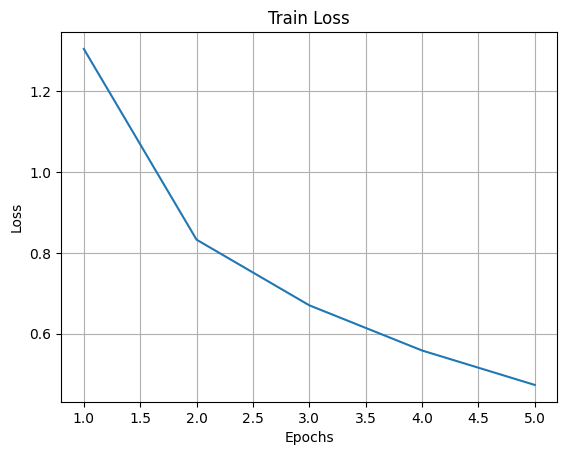

In [12]:
#조건문의 조건 (모델새로 학습)이 True이면 실행(새로학습)
if new_model_train:
    optimizer = optim.Adam(model.parameters(), lr = LR)
    loss_history = Train(model, train_DL, criterion, optimizer, EPOCH)

    torch.save(model, save_model_path)

    plt.figure()
    plt.plot(range(1,EPOCH+1),loss_history)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Train Loss")
    plt.grid()

In [13]:
load_model = torch.load(save_model_path, map_location=DEVICE, weights_only=False)

In [14]:
#학습된 모델 그대로 가져와서 test실행
Test(load_model, test_DL)
print(count_params(load_model))

Test accuracy: 8053/10000 (80.5 %)
1527018


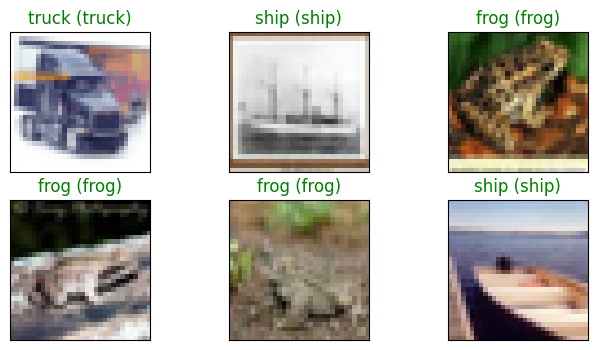

In [15]:
Test_plot(load_model,test_DL)

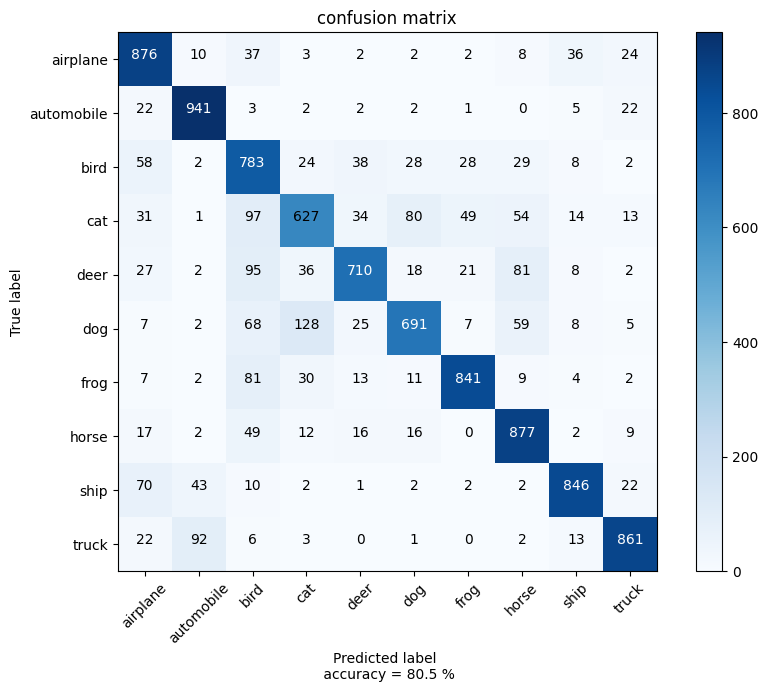

In [16]:
confusion = get_conf(load_model, test_DL)
plot_confusion_matrix(confusion, test_DS.classes)
plt.xticks(rotation=45);